<a href="https://colab.research.google.com/github/Macleyn/ML/blob/main/%D0%B3%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F_%D0%BF%D0%BE%D1%8D%D0%B7%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Almost Shakespeare

Let's try to generate some Shakespeare poetry using RNNs. The sonnets file is available in the notebook directory.

Text generation can be designed in several steps:
    
1. Data loading
2. Dictionary generation
3. Data preprocessing
4. Model (neural network) training
5. Text generation (model evaluation)

### Data loading

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`).

Simple preprocessing is already done for you in the next cell: all technical info is dropped.

**Alternatively**

You could use file `onegin.txt` with Russian texts or your natve language poetry to be able to assess results quality.

**Note: In case of Onegin text you need to adjust reading procedure yourself!!!** (this file has a bit different format than `sonnets.txt`)

In [62]:
!wget -nc https://raw.githubusercontent.com/girafe-ai/ml-course/7ec90e0d1c1e45efc20439566e5fb46dfb0dfad0/data/poetry/sonnets.txt
!wget -nc https://raw.githubusercontent.com/girafe-ai/ml-course/7ec90e0d1c1e45efc20439566e5fb46dfb0dfad0/data/poetry/onegin.txt

File ‘sonnets.txt’ already there; not retrieving.

File ‘onegin.txt’ already there; not retrieving.



In [63]:
with open("sonnets.txt", "r") as iofile:
    text = iofile.readlines()

TEXT_START = 43
TEXT_END = -368
text = text[TEXT_START:TEXT_END]
assert len(text) == 2618

print('\n'.join(text[:25]))

  I



  From fairest creatures we desire increase,

  That thereby beauty's rose might never die,

  But as the riper should by time decease,

  His tender heir might bear his memory:

  But thou, contracted to thine own bright eyes,

  Feed'st thy light's flame with self-substantial fuel,

  Making a famine where abundance lies,

  Thy self thy foe, to thy sweet self too cruel:

  Thou that art now the world's fresh ornament,

  And only herald to the gaudy spring,

  Within thine own bud buriest thy content,

  And tender churl mak'st waste in niggarding:

    Pity the world, or else this glutton be,

    To eat the world's due, by the grave and thee.



  II



  When forty winters shall besiege thy brow,

  And dig deep trenches in thy beauty's field,

  Thy youth's proud livery so gazed on now,

  Will be a tatter'd weed of small worth held:

  Then being asked, where all thy beauty lies,

  Where all the treasure of thy lusty days;



## Preprocessing

In opposite to the in-class practice, this time we want to predict complex text.

In class we've discussed ways to preprocess textual data. You need to choose your way to preprocess data, tokenize it and pack it to samples.

You could use preprocessing from text translation class.

In [64]:
import re
import random
import math
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [65]:
# Your great code here
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

raw_text = "".join(text).lower()
raw_text = re.sub(r"[^a-z\n ,;:!\?'\.\-\(\)]", "", raw_text)
raw_text = re.sub(r"[ \t]+", " ", raw_text)
raw_text = "\n".join(line.strip() for line in raw_text.splitlines())
raw_text = re.sub(r"\n{3,}", "\n\n", raw_text).strip() + "\n"

print("Corpus length in characters:", len(raw_text))
print("Corpus preview:\n")
print(raw_text[:700])


Corpus length in characters: 94994
Corpus preview:

i

from fairest creatures we desire increase,
that thereby beauty's rose might never die,
but as the riper should by time decease,
his tender heir might bear his memory:
but thou, contracted to thine own bright eyes,
feed'st thy light's flame with self-substantial fuel,
making a famine where abundance lies,
thy self thy foe, to thy sweet self too cruel:
thou that art now the world's fresh ornament,
and only herald to the gaudy spring,
within thine own bud buriest thy content,
and tender churl mak'st waste in niggarding:
pity the world, or else this glutton be,
to eat the world's due, by the grave and thee.

ii

when forty winters shall besiege thy brow,
and dig deep trenches in thy beauty's 


Put all the tokens, that you've seen in the text, into variable.

In [66]:
tokens = sorted(set(raw_text))
print("Number of unique tokens:", len(tokens))
print(tokens)

Number of unique tokens: 38
['\n', ' ', '!', "'", '(', ')', ',', '-', '.', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


Create dictionary `token_to_idx = {<token>: <index>}` and dictionary `idx_to_token = {<index>: <token>}`

In [67]:
token_to_idx = {token: idx for idx, token in enumerate(tokens)}
idx_to_token = {idx: token for token, idx in token_to_idx.items()}

encoded_text = np.array([token_to_idx[ch] for ch in raw_text], dtype=np.int64)

print("Vocab size:", len(token_to_idx))
print("First 40 encoded symbols:", encoded_text[:40].tolist())
print("Decoded back:", "".join(idx_to_token[i] for i in encoded_text[:40]))

Vocab size: 38
First 40 encoded symbols: [20, 0, 0, 17, 29, 26, 24, 1, 17, 12, 20, 29, 16, 30, 31, 1, 14, 29, 16, 12, 31, 32, 29, 16, 30, 1, 34, 16, 1, 15, 16, 30, 20, 29, 16, 1, 20, 25, 14, 29]
Decoded back: i

from fairest creatures we desire incr


*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [68]:
class CharSequenceDataset(Dataset):
  def __init__(self, encoded: np.ndarray, seq_len: int = 30, stride: int = 20):
    self.data = torch.tensor(encoded, dtype = torch.long)
    self.seq_len = seq_len
    self.starts = list(range(0, len(self.data) - seq_len - 1, stride))

  def __len__(self):
    return len(self.starts)

  def __getitem__(self, idx):
    start = self.starts[idx]
    x = self.data[start : start + self.seq_len]
    y = self.data[start + 1 : start + self.seq_len + 1]
    return x, y

SEQ_LEN = 80
STRIDE = 3
BATCH_SIZE = 128

dataset = CharSequenceDataset(encoded_text, seq_len=SEQ_LEN, stride=STRIDE)
print("Dataset size:", len(dataset))

x_example, y_example = dataset[0]
print("x:", repr("".join(idx_to_token[int(i)] for i in x_example)))
print("y:", repr("".join(idx_to_token[int(i)] for i in y_example)))


Dataset size: 31638
x: "i\n\nfrom fairest creatures we desire increase,\nthat thereby beauty's rose might n"
y: "\n\nfrom fairest creatures we desire increase,\nthat thereby beauty's rose might ne"


In [69]:
class CharRNN(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        hidden_size: int = 32,
        embedding_dim: int = 10,
        rnn_type: str = "RNN"
    ):
        super().__init__()

        self.vocab_size = vocab_size
        self.hidden = hidden_size
        self.emb_dim = embedding_dim
        self.rnn_type = rnn_type

        if rnn_type == "RNN":
            rnn_layer = nn.RNN
        elif rnn_type == "LSTM":
            rnn_layer = nn.LSTM
        else:
            raise ValueError("rnn_type must be 'RNN' or 'LSTM'")

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim
        )

        self.rnn = rnn_layer(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output = nn.Linear(
            in_features=hidden_size,
            out_features=vocab_size
        )

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        rnn_out, hidden = self.rnn(x, hidden)
        logits = self.output(rnn_out)
        return logits, hidden

In [70]:
def train_language_model(
        model: nn.Module,
        dataset: Dataset,
        epochs: int,
        max_batches_per_epoch: int,
        lr: float = 1e-2,
        batch_size: int = BATCH_SIZE
):
    model.to(device)
    model.train()

    loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    optimizer = torch.optim.Adam(params = model.parameters(), lr = lr)
    history = []

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        n_batches = 0
        t0 = time.time()

        for batch_idx, (x, y) in enumerate(loader):
            if batch_idx >=  max_batches_per_epoch:
                break

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits, _ = model(x)
            loss = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), y.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        history.append(avg_loss)
        perplexity = math.exp(avg_loss)
        print(
            f"epoch {epoch:02d} | loss={avg_loss:.4f} | "
            f"perplexity={perplexity:.2f} | time={time.time() - t0:.1f}s"
        )

    return history



In [71]:
def plot_history(history, title):
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(history) + 1), history, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title(title)
    plt.grid(True)
    plt.show()

In [72]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

RNN_EPOCHS = 15
RNN_MAX_BATCHES = 120
LSTM_EPOCHS = 30
LSTM_MAX_BATCHES = 120
HIDDEN_SIZE = 128
EMBEDDING_DIM = 15

SEQ_LEN = 80
STRIDE = 3
BATCH_SIZE = 128

Device: cuda


In [73]:
rnn_model = CharRNN(vocab_size=len(tokens), hidden_size=HIDDEN_SIZE, embedding_dim = EMBEDDING_DIM,  rnn_type="RNN")
rnn_history = train_language_model(
    rnn_model,
    dataset,
    epochs=RNN_EPOCHS,
    max_batches_per_epoch=RNN_MAX_BATCHES,
    lr=1e-2,
)


epoch 01 | loss=2.0824 | perplexity=8.02 | time=0.4s
epoch 02 | loss=1.6568 | perplexity=5.24 | time=0.4s
epoch 03 | loss=1.5512 | perplexity=4.72 | time=0.4s
epoch 04 | loss=1.4970 | perplexity=4.47 | time=0.4s
epoch 05 | loss=1.4608 | perplexity=4.31 | time=0.4s
epoch 06 | loss=1.4390 | perplexity=4.22 | time=0.4s
epoch 07 | loss=1.4193 | perplexity=4.13 | time=0.4s
epoch 08 | loss=1.4093 | perplexity=4.09 | time=0.4s
epoch 09 | loss=1.3979 | perplexity=4.05 | time=0.4s
epoch 10 | loss=1.3921 | perplexity=4.02 | time=0.4s
epoch 11 | loss=1.3852 | perplexity=4.00 | time=0.4s
epoch 12 | loss=1.3805 | perplexity=3.98 | time=0.5s
epoch 13 | loss=1.3781 | perplexity=3.97 | time=0.6s
epoch 14 | loss=1.3729 | perplexity=3.95 | time=0.7s
epoch 15 | loss=1.3753 | perplexity=3.96 | time=0.5s


Plot the loss function (axis X: number of epochs, axis Y: loss function).

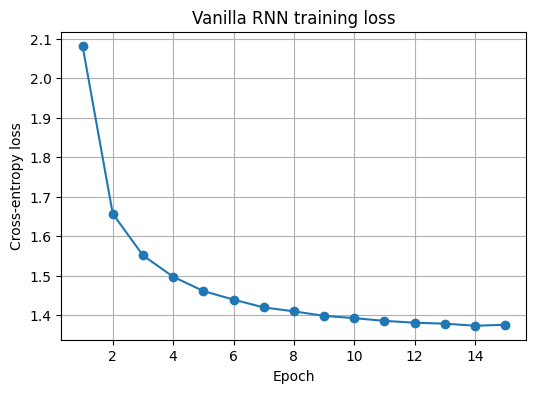

In [74]:
# Your plot code here
plot_history(rnn_history, "Vanilla RNN training loss")

In [75]:
# An example of generated text. There is no function `generate_text` in the code above.
# print(generate_text(length=500, temperature=0.2))

@torch.no_grad()
def generate_text(model, start_text: str = "shall i compare thee", length: int = 500, temperature: float = 0.5):
    model.eval()
    model.to(device)

    start_text = start_text.lower()
    generated = [ch for ch in start_text if ch in token_to_idx]
    if not generated:
        generated = ["\n"]

    input_ids = torch.tensor([[token_to_idx[ch] for ch in generated]], dtype=torch.long, device=device)
    hidden = None

    logits, hidden = model(input_ids, hidden)
    current_id = input_ids[:, -1:]

    for _ in range(length):
        logits, hidden = model(current_id, hidden)
        next_logits = logits[:, -1, :] / max(temperature, 1e-6)
        probs = F.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        generated.append(idx_to_token[int(next_id.item())])
        current_id = next_id

    return "".join(generated)

print(generate_text(rnn_model, start_text="shall i compare thee", length=500, temperature=0.5))


shall i compare theek,
i do show me well have subjects life, be the roind thy spower love the could the beauty by another things in my self in the great gazen
to have i not on my painted confound.
if not the proceed?
or who have so my self the such is as it of thee sweet fair the sporth
the soult show'd of the so showest doth the very my breath in my allow both strength of thy self so my soul well make with me to show my spirit of his soul muth then wringles be say,
can so brand,
then i love to dutis shall show my 


### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

epoch 01 | loss=2.0861 | perplexity=8.05 | time=0.7s
epoch 02 | loss=1.5639 | perplexity=4.78 | time=0.7s
epoch 03 | loss=1.4035 | perplexity=4.07 | time=0.6s
epoch 04 | loss=1.2974 | perplexity=3.66 | time=0.7s
epoch 05 | loss=1.2162 | perplexity=3.37 | time=0.7s
epoch 06 | loss=1.1652 | perplexity=3.21 | time=0.7s
epoch 07 | loss=1.1256 | perplexity=3.08 | time=0.7s
epoch 08 | loss=1.1000 | perplexity=3.00 | time=0.7s
epoch 09 | loss=1.0757 | perplexity=2.93 | time=0.7s
epoch 10 | loss=1.0600 | perplexity=2.89 | time=0.7s
epoch 11 | loss=1.0444 | perplexity=2.84 | time=0.7s
epoch 12 | loss=1.0322 | perplexity=2.81 | time=0.7s
epoch 13 | loss=1.0254 | perplexity=2.79 | time=0.7s
epoch 14 | loss=1.0149 | perplexity=2.76 | time=0.7s
epoch 15 | loss=1.0053 | perplexity=2.73 | time=0.7s
epoch 16 | loss=0.9955 | perplexity=2.71 | time=0.7s
epoch 17 | loss=0.9883 | perplexity=2.69 | time=0.7s
epoch 18 | loss=0.9843 | perplexity=2.68 | time=0.7s
epoch 19 | loss=0.9776 | perplexity=2.66 | tim

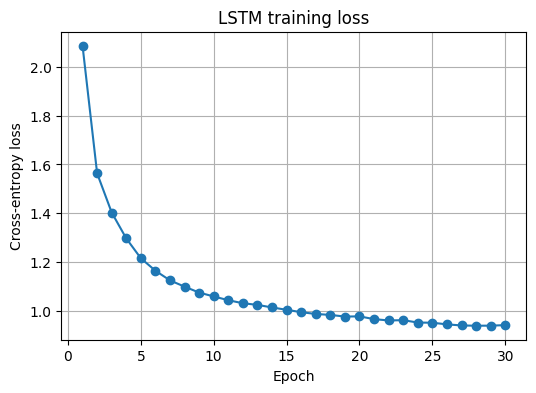

Final RNN loss:  1.3753
Final LSTM loss: 0.9425


In [76]:
# Your beautiful code here
lstm_model = CharRNN(
    vocab_size=len(tokens),
    hidden_size=HIDDEN_SIZE,
    embedding_dim=EMBEDDING_DIM,
    rnn_type="LSTM",
)

lstm_history = train_language_model(
    lstm_model,
    dataset,
    epochs=LSTM_EPOCHS,
    max_batches_per_epoch=LSTM_MAX_BATCHES,
    lr=1e-2,
    batch_size=BATCH_SIZE,
)

plot_history(lstm_history, "LSTM training loss")

print(f"Final RNN loss:  {rnn_history[-1]:.4f}")
print(f"Final LSTM loss: {lstm_history[-1]:.4f}")


Generate text using the trained net with different `temperature` parameter: `(0.1, 0.2, 0.5, 1.0, 2.0)`.

Evaluate the results visually, try to interpret them.

In [77]:
# Text generation with different temperature values here
for temperature in [0.1, 0.2, 0.5, 1.0, 2.0]:
    print("=" * 80)
    print(f"temperature = {temperature}")
    print(generate_text(lstm_model, start_text="shall i compare thee", length=500, temperature=temperature))


temperature = 0.1
shall i compare thee;
now i shall stay soul, the clear that my mistress' eyes.

lxviii

thus in the world the despised and find.
then the dear hearted, and therefore have i shall stand the strengt it thee.

cxxviii

how can i then i seal the world may see thee,
and all my soul remembers than the strength of love?
before, how thine own burning stay!
o'ever i three a death thy self thy beauty lies.

cxlvi

my love is my brought, which i fortune the brough thee in thee.

ii

my rourse know thy face shall be my mind,
m
temperature = 0.2
shall i compare thee;
now i shall strained touches rhear so shall i have against the wrong.
in made me that thou that which yourself spites thee,
and abundance alone, which i fortune the stall'd woman't in me.

cxxxiv

so is it not seem born fresh well belov'd of men.

cxxxiii

thy sweet self-love the wise in me then he taken
to the stars do i praise thee in the world with mend,
and windous change the world will be whom from me whose most 

### Saving and loading models

Save the model to the disk, then load it and generate text.
Follow guides from [this tutorial](https://pytorch.org/tutorials/beginner/saving_loading_models.html).

You need to use `Save/Load state_dict (Recommended)` section aka save state dict.

In [78]:
# Saving and loading code here
model_path = "char_lstm_poetry_state_dict.pt"

torch.save(lstm_model.state_dict(), model_path)

loaded_lstm_model = CharRNN(
    vocab_size=len(tokens),
    hidden_size=HIDDEN_SIZE,
    embedding_dim=EMBEDDING_DIM,
    rnn_type="LSTM",
)
loaded_lstm_model.load_state_dict(torch.load(model_path, map_location=device))
loaded_lstm_model.to(device)

print(generate_text(loaded_lstm_model, start_text="shall i compare thee", length=500, temperature=0.5))


shall i compare thee;
now is the senses song,
and do not so remembrance some spirit?
when such full do i praise.

xxx

no let beauty's dost hell of each doth diseas'd from me then.

cxli

so in the world with thee bright that thee,
the untomber stand and straine profan right show my spirit?
as flowers debtor'd with fortune impegain.

cxlvi

mine eyes sweet love the world's rain'd of age in the world with sweet self-same to thee:
the ofth thee me than the world to me most by the world doth state
which i then i seal 


## Additional materials on topic

1. [Andrew Karpathy blog post about RNN.](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)\
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with [PyTorch examples](https://github.com/spro/practical-pytorch`)